# 02 · Clustering a map into phases

**Goal.** Group indents that behave alike — *without labels* — and turn the
result into a **phase map**. This is the workhorse of unsupervised
nanomechanics.

You will learn:
1. **k-means** and how to *choose k* with the **silhouette**,
2. **Gaussian Mixture Models** for soft labels and an **uncertainty** map,
3. **HDBSCAN** for density-based clustering that can flag outliers,
4. how to check that different methods **agree** (Adjusted Rand Index).

In [1]:
# --- setup: find the repo (auto-clone on Colab), load helpers, set plot style ---
import os, sys, subprocess
def _find_src():
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None
if _find_src() is None:                    # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)
sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import mecanano_ml as mm
mm.set_style()
print("helpers loaded from:", mm.__file__)

helpers loaded from: /tmp/stage/repo/src/mecanano_ml/__init__.py


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
rng = np.random.default_rng(0)

## 1 · Features
Same three standardised features as before, for the full Al–Cu map.

In [3]:
df = mm.load_map("alcu_2um")
Xs = StandardScaler().fit_transform(df[["H","E","HE"]].values)
print("indents:", Xs.shape[0])

indents: 40000


## 2 · How many phases? The silhouette

k-means needs `k` up front. The **silhouette score** measures how well each
point sits in its cluster versus the next-nearest one — we pick the `k` with
the highest score. (Silhouette is O(n²), so we evaluate it on a random
subsample.)

silhouettes: [0.611 0.48  0.432 0.406 0.394]


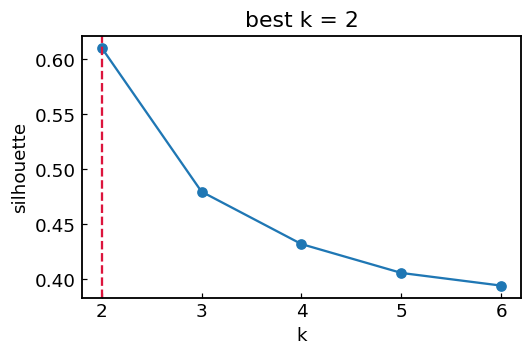

In [4]:
ks = range(2, 7)
sil = []
for k in ks:
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    sil.append(silhouette_score(Xs, lab, sample_size=4000, random_state=0))
best_k = list(ks)[int(np.argmax(sil))]
fig, ax = plt.subplots(figsize=(5,3.4))
ax.plot(list(ks), sil, "o-"); ax.axvline(best_k, ls="--", c="crimson")
ax.set_xlabel("k"); ax.set_ylabel("silhouette"); ax.set_title(f"best k = {best_k}")
fig.tight_layout(); print("silhouettes:", np.round(sil,3))

## 3 · k-means phase map
Fit at the chosen `k` and paint the labels back onto the indent positions — the two phases appear as coherent regions.

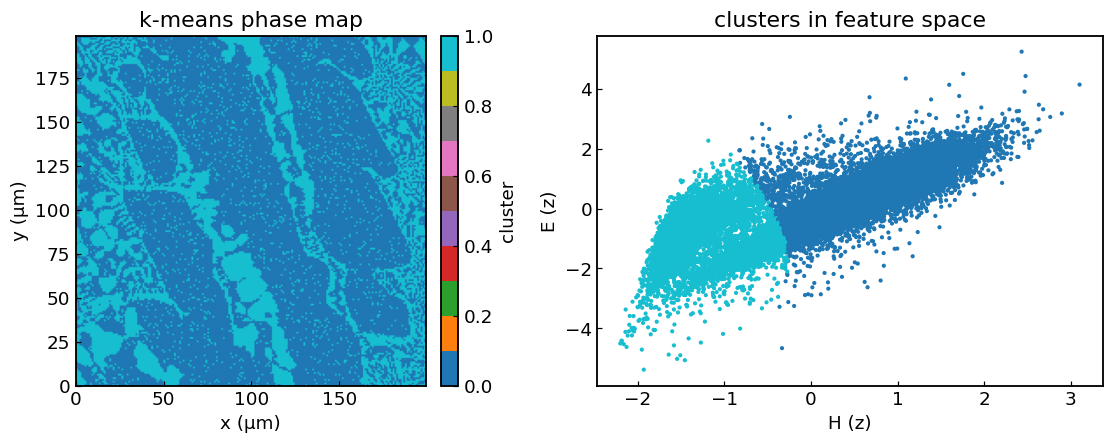

In [5]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(Xs)
df["cluster"] = km.labels_
gmap, ext = mm.map_to_grid(df, "cluster")
fig, ax = plt.subplots(1,2, figsize=(11,4.2))
mm.plot_map(gmap, ext, ax=ax[0], cmap="tab10", label="cluster", title="k-means phase map")
sc = ax[1].scatter(Xs[:,0], Xs[:,1], c=km.labels_, s=3, cmap="tab10")
ax[1].set_xlabel("H (z)"); ax[1].set_ylabel("E (z)"); ax[1].set_title("clusters in feature space")
fig.tight_layout()

## 4 · Soft labels and uncertainty (GMM)

k-means gives every indent a hard label. A **Gaussian Mixture Model** gives a
*probability* of belonging to each phase — so we can map **confidence** and
see it drop at phase **boundaries**, where indents mix both phases.

median confidence: 1.0


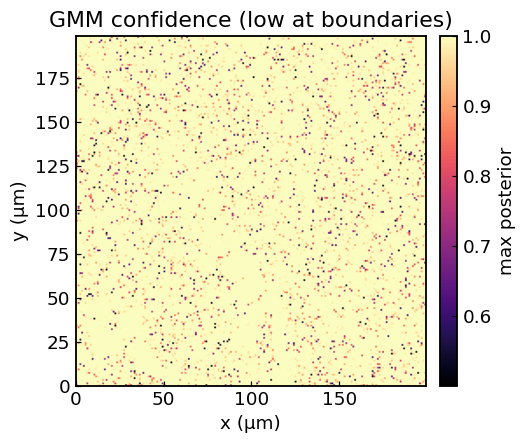

In [6]:
gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=0).fit(Xs)
proba = gmm.predict_proba(Xs)
df["gmm"] = gmm.predict(Xs)
df["conf"] = proba.max(1)                       # confidence = top posterior
gc, ext = mm.map_to_grid(df, "conf")
fig, ax = plt.subplots(figsize=(5.2,4.2))
mm.plot_map(gc, ext, ax=ax, cmap="magma", label="max posterior", title="GMM confidence (low at boundaries)")
fig.tight_layout()
print("median confidence:", round(float(df['conf'].median()),3))

## 5 · Density clustering (HDBSCAN)

HDBSCAN needs **no k**; it finds clusters as dense regions and labels sparse
points as **noise** (`-1`). Good when phase fractions are very unequal or
cluster shapes are irregular. We run it on a subsample for speed.

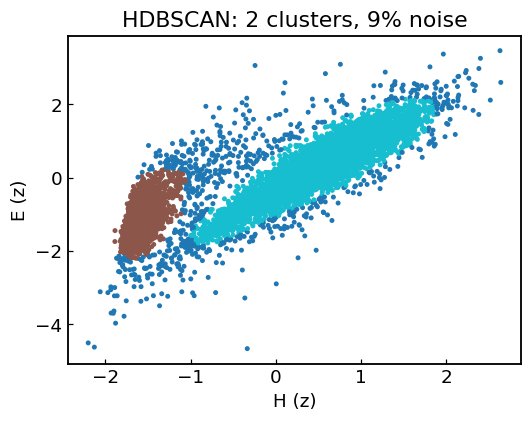

In [7]:
import hdbscan
idx = rng.choice(Xs.shape[0], 8000, replace=False)
hl = hdbscan.HDBSCAN(min_cluster_size=150).fit_predict(Xs[idx])
n_cl = len(set(hl)) - (1 if -1 in hl else 0)
fig, ax = plt.subplots(figsize=(5,4))
sc = ax.scatter(Xs[idx,0], Xs[idx,1], c=hl, s=5, cmap="tab10")
ax.set_xlabel("H (z)"); ax.set_ylabel("E (z)")
ax.set_title(f"HDBSCAN: {n_cl} clusters, {(hl==-1).mean()*100:.0f}% noise"); fig.tight_layout()

## 6 · Do the methods agree?
The **Adjusted Rand Index** compares two partitions (1.0 = identical, 0 = chance). Strong agreement means the phase split is *robust*, not an artefact of one algorithm.

In [8]:
ari = adjusted_rand_score(df["cluster"], df["gmm"])
print(f"ARI(k-means, GMM) = {ari:.2f}")

ARI(k-means, GMM) = 0.86


## Recap
- The **silhouette** turns *"how many phases?"* into a defensible number.
- **GMM** adds calibrated **uncertainty** — most valuable at phase boundaries.
- **HDBSCAN** needs no `k` and isolates outliers.
- Cross-checking with **ARI** shows the segmentation is robust.

**Next:** `03_supervised_trees_rf_shap.ipynb` — once phases are named, train a
fast, interpretable classifier and see *why* it decides.